# Random Forest Model — Predicción de Ictus

En este notebook se entrena un modelo **Random Forest** para predecir la probabilidad de sufrir un **ictus (stroke)** a partir de variables demográficas y médicas del dataset.

El objetivo es:
- entrenar el modelo
- evaluar su rendimiento
- identificar las variables más importantes en la predicción

## 1. Importar librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

## 2. Cargar el dataset

In [3]:
df = pd.read_csv("src/data/healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. Revisión rápida del dataset

Comprobamos:
- tamaño del dataset
- tipos de datos
- valores nulos
- distribución de la variable objetivo (stroke)

In [4]:
df.shape

(5110, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [6]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

## 4. Preparación de los datos

- Eliminamos la columna `id` (no aporta información al modelo)
- Separamos:
  - X: variables predictoras
  - y: variable objetivo (`stroke`)

In [8]:
df = df.drop(columns=["id"])

X = df.drop(columns=["stroke"])
y = df["stroke"]

## 5. Identificar variables numéricas y categóricas

In [9]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numéricas:", list(num_cols))
print("Categóricas:", list(cat_cols))

Numéricas: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


/var/folders/mh/wrpn4gjd31qb792h_qfd1s6h0000gn/T/ipykernel_80440/4267013898.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


In [10]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "string"]).columns

print("Numéricas:", list(num_cols))
print("Categóricas:", list(cat_cols))

Numéricas: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


## 6. Crear pipeline de preprocesamiento

Preparamos los datos antes de entrenar el modelo:

Variables numéricas:
- imputación con la mediana

Variables categóricas:
- imputación con valor más frecuente
- codificación OneHot

In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

## 7. División de datos (train / test)

Dividimos el dataset en:

- 80% entrenamiento
- 20% test

Usamos stratify porque el dataset está desbalanceado.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 8. Crear modelo Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

## 9. Entrenar el modelo

In [14]:
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 10. Predicciones del modelo

In [15]:
y_pred = rf_pipeline.predict(X_test)

y_prob = rf_pipeline.predict_proba(X_test)[:,1]

## 11. Evaluación del modelo

In [16]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



In [17]:
roc_auc_score(y_test, y_prob)

0.7696090534979424

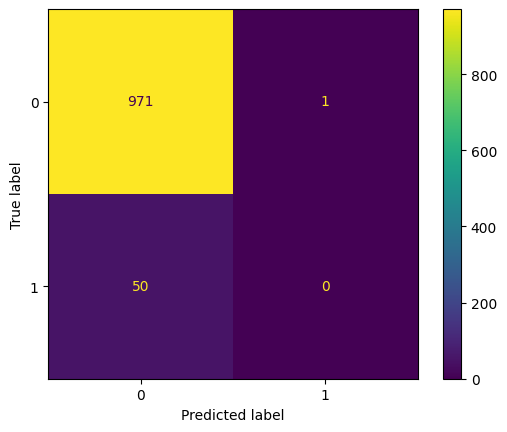

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

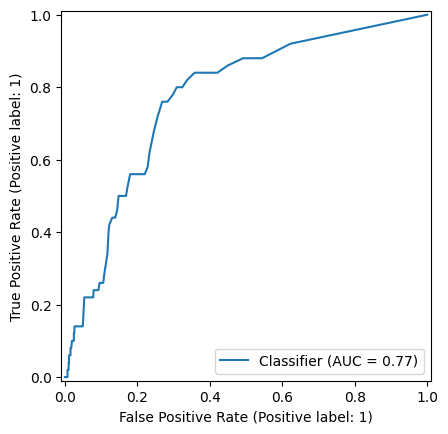

In [19]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.show()

## 15. Conclusiones del modelo Random Forest

En este trabajo se entrenó un modelo **Random Forest** para predecir la probabilidad de sufrir un ictus utilizando variables demográficas y médicas del dataset.

El modelo obtuvo una **accuracy del 95%**, lo que inicialmente parece indicar un buen rendimiento. Sin embargo, esta métrica está influenciada por el fuerte **desbalanceo del dataset**, ya que la gran mayoría de los registros corresponden a pacientes sin ictus.

Al analizar métricas más relevantes para problemas médicos, se observa que:

- El modelo predice correctamente casi todos los casos **sin ictus** (recall = 1.00 para la clase 0).
- Sin embargo, **no consigue detectar ningún caso de ictus** (recall = 0.00 para la clase 1).
- Esto significa que el modelo tiende a clasificar prácticamente todos los pacientes como **no ictus**.

La **matriz de confusión** confirma este comportamiento:
- 971 pacientes sin ictus fueron correctamente clasificados.
- 50 pacientes que sí sufrieron ictus fueron clasificados incorrectamente como no ictus.

Por otro lado, el modelo obtiene un **ROC AUC de aproximadamente 0.77**, lo que indica que el modelo sí es capaz de distinguir entre ambas clases cuando se consideran las probabilidades, aunque el umbral de clasificación actual no permite detectar los casos positivos.

En conclusión, aunque el modelo Random Forest muestra una buena capacidad general de discriminación, **no es adecuado en su estado actual para detectar ictus**, ya que falla en identificar los casos positivos. 

Este resultado refleja un problema común en datasets médicos: **el desbalanceo entre clases**. Para mejorar el modelo sería necesario aplicar técnicas adicionales como:
- balanceo de clases (por ejemplo SMOTE)
- ajuste del umbral de clasificación
- optimización de hiperparámetros
- o el uso de métricas orientadas a maximizar el recall de la clase positiva.

Estas mejoras permitirían aumentar la capacidad del modelo para identificar pacientes con riesgo de ictus, lo cual es especialmente importante en aplicaciones médicas donde **detectar los casos positivos es crítico**.

## 16. Ajuste del umbral de clasificación

Por defecto, los modelos de clasificación utilizan un umbral de 0.5 para decidir la clase final.  
En datasets desbalanceados, este umbral puede ser demasiado alto para detectar la clase minoritaria.

Probamos reducir el umbral para mejorar la detección de ictus.

In [28]:
threshold = 0.2

y_pred_adjusted = (y_prob >= threshold).astype(int)

In [29]:
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       972
           1       0.14      0.16      0.15        50

    accuracy                           0.91      1022
   macro avg       0.55      0.55      0.55      1022
weighted avg       0.92      0.91      0.91      1022



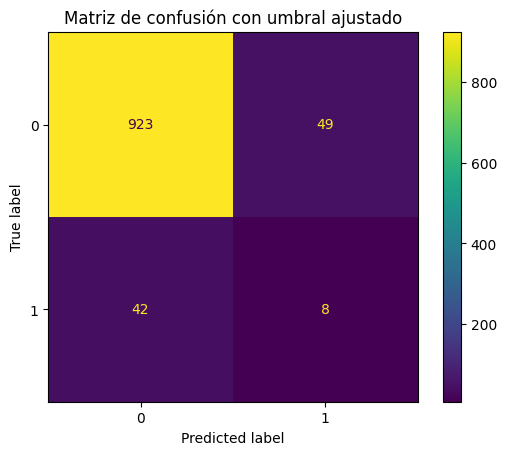

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_adjusted)

plt.title("Matriz de confusión con umbral ajustado")

plt.show()

### Conclusión del ajuste de umbral

Al reducir el umbral de clasificación, el modelo aumenta su capacidad para detectar casos de ictus. Aunque esto puede generar más falsos positivos y reducir ligeramente la accuracy global, permite identificar mejor a los pacientes con riesgo real.

Este ajuste es especialmente relevante en problemas médicos, donde es preferible detectar posibles casos de enfermedad aunque ello implique realizar evaluaciones adicionales. Por tanto, modificar el umbral de decisión puede ser una estrategia útil para mejorar la utilidad práctica del modelo.